In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

In [2]:
df = data.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.shape

(6468, 24)

In [4]:
df.isnull().sum()

Gold_Open       0
Gold_High       0
Gold_Low        0
Gold_Close      0
Gold_Volume     0
DXY             0
SP500           0
Oil             0
VIX             0
Lag1            0
Lag7            0
MA7             0
MA30            0
EMA20           0
Daily_Return    0
RSI             0
MACD            0
MACD_Signal     0
MACD_Hist       0
BB_Upper        0
BB_Middle       0
BB_Lower        0
ATR             0
Target          0
dtype: int64

In [5]:
# day-of-week / month seasonality, added straight to df so the latest row already has everything it needs later
dow = df.index.dayofweek
df["dow_sin"] = np.sin(2*np.pi*dow/7)
df["dow_cos"] = np.cos(2*np.pi*dow/7)

month = df.index.month
df["month_sin"] = np.sin(2*np.pi*month/12)
df["month_cos"] = np.cos(2*np.pi*month/12)

print(df.shape)

(6468, 28)


In [8]:
df[["Gold_Close","RSI","MACD","DXY","VIX"]].tail()

,Gold_Close,RSI,MACD,DXY,VIX
Date,,,,,
2026-07-24,4067.600098,45.939508,-51.155755,101.470001,18.580000
2026-07-27,4074.500000,46.480858,-46.768670,101.510002,18.670000
2026-07-28,4036.300049,43.862116,-45.845807,101.379997,18.209999
2026-07-29,4034.699951,43.750924,-44.727951,100.800003,20.660000
2026-07-30,4100.100098,49.397363,-38.125311,100.010002,17.090000


### Feature Engineering
we point `FEATURE_COLS` at the columns and add the karat price + the seasonality terms. `Gold_Close` itself is dropped from the feature list since `24K` is just a rescaled copy of it, keeping both would be redundant

The target is the 24K price 21 trading days out (~1 month ahead).
- Important: the dataset's own `Target` column is next-day close, not 1-month-ahead, so it gets dropped rather than used, using it as a feature would leak almost the exact answer

In [7]:
df.columns

Index(['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
       'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7', 'MA30', 'EMA20',
       'Daily_Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'Target', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos'],
      dtype='str')

In [9]:
HORIZON = 21  # ~1 trading month ahead (21 trading days)
df['Target'] = df["Gold_Close"].shift(-HORIZON)
df = df.dropna(subset=["Target"])

X = df.drop(columns=['Target'])
y = df['Target']

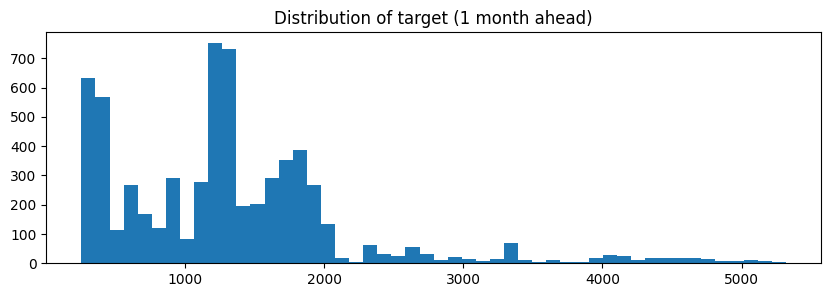

Skew: 1.6380445326263973


In [11]:
# Target distribution check (skew)
plt.figure(figsize=(10,3))
plt.hist(df["Target"], bins=50)
plt.title("Distribution of target (1 month ahead)")
plt.show()
print("Skew:", df["Target"].skew())

### Train / Validation / Test Split
Since this is time-series data we split by date instead of shuffling.
70% train, 15% val, 15% test, in that order. Shuffling would let the model peek at future prices during training, which isn't realistic

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5157, 27)  Test: (1290, 27)


### Scaling
Scaled X and y with StandardScaler, fitting only on the training set so nothing from validation/test leaks into it

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

s_train = scaler.fit_transform(X_train)
s_test = scaler.transform(X_test)

X_train_s = pd.DataFrame(s_train, columns=X.columns, index=X_train.index)
X_test_s = pd.DataFrame(s_test, columns=X.columns, index=X_test.index)

### Baselines
Before trusting whatever the ANN outputs, we wanted something to compare it against, a naive random-walk baseline (just "price in a month = price today") and a linear regression on the same features

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Naive baseline: assume no change over the horizon
naive_pred = X_test["Gold_Close"].values

# Linear regression baseline
lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train)
lin_pred = lin_reg.predict(X_test_s)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label:30s} MAE={mae:7.3f}  RMSE={rmse:7.3f}  MAPE={mape:5.2f}%  R2={r2:6.4f}")

    return dict(MAE=mae, RMSE=rmse, MAPE=mape, R2=r2)

baseline_results = {}
baseline_results["naive"] = evaluate(y_test, naive_pred, "Naive (no-change) baseline")
baseline_results["linreg"] = evaluate(y_test, lin_pred, "Linear Regression baseline")

Naive (no-change) baseline     MAE=107.302  RMSE=162.796  MAPE= 3.75%  R2=0.9720
Linear Regression baseline     MAE=115.949  RMSE=172.555  MAPE= 4.00%  R2=0.9685


### ANN Architecture (with Regularization)
Dense layers with L2 and Dropout so it doesn't just memorize the training set. linear output since this is regression

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

def build_model(n_features, units1=128, units2=64, units3=32, dropout1=0.3, dropout2=0.2, l2reg=1e-3, lr=1e-3):
    
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(units1, activation="relu", kernel_regularizer=regularizers.l2(l2reg)),
        layers.Dropout(dropout1),
        layers.Dense(units2, activation="relu", kernel_regularizer=regularizers.l2(l2reg)),
        layers.Dropout(dropout2),
        layers.Dense(units3, activation="relu"),
        layers.Dense(1, activation="linear"),   # linear output -> regression
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mae",              # more robust to outliers than MSE
        metrics=["mae", "mse"],
    )
    return model

build_model(X_train_s.shape[1]).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,953 (54.50 KB)

 Non-trainable params: 0 (0.00 B)

### Hyperparameter Tuning (manual search)
Tried a handful of combos of layer sizes, dropout, L2 strength, and learning rate, each trained with early stopping, and kept whichever one had the lowest validation MAE.

In [23]:
configs = [
    dict(units1=64,  units2=32,  units3=16, dropout1=0.2, dropout2=0.1, l2reg=1e-4, lr=1e-3),
    dict(units1=128, units2=64,  units3=32, dropout1=0.3, dropout2=0.2, l2reg=1e-3, lr=1e-3),
    dict(units1=128, units2=64,  units3=32, dropout1=0.4, dropout2=0.3, l2reg=1e-3, lr=5e-4),
    dict(units1=256, units2=128, units3=64, dropout1=0.4, dropout2=0.3, l2reg=1e-2, lr=1e-3),
]

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tuning_results = []
for i, cfg in enumerate(configs):
    tf.keras.backend.clear_session()
    model = build_model(X_train_s.shape[1], **cfg)

    hist = model.fit(
        X_train_s,
        y_train,
        validation_split=0.2,
        epochs=80,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    best_val_mae = min(hist.history["val_mae"])
    tuning_results.append({
        "config": cfg,
        "val_mae_scaled": best_val_mae
    })
    
    print(f"Config {i}: {cfg} -> val_mae(scaled)={best_val_mae:.4f}")

best_cfg = min(tuning_results, key=lambda r: r["val_mae_scaled"])["config"]
print("\nBest config:", best_cfg)


Config 0: {'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001} -> val_mae(scaled)=47.2142
Config 1: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.3, 'dropout2': 0.2, 'l2reg': 0.001, 'lr': 0.001} -> val_mae(scaled)=57.4490
Config 2: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.001, 'lr': 0.0005} -> val_mae(scaled)=49.8302
Config 3: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001} -> val_mae(scaled)=57.6271

Best config: {'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001}


### Training the Final Model
Using the best config from the tuning step, now with the full callback stack,EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [11]:
tf.keras.backend.clear_session()
final_model = build_model(X_train_s.shape[1], **best_cfg)

cb_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    callbacks.ModelCheckpoint("best_gold_model.keras", monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6),
]

history = final_model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=300, batch_size=32,
    callbacks=cb_list, verbose=1,
)

Epoch 1/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5529 - mae: 0.2201 - mse: 0.0917 - val_loss: 0.8938 - val_mae: 0.1757 - val_mse: 0.0494 - learning_rate: 0.0010
Epoch 2/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5990 - mae: 0.1533 - mse: 0.0407 - val_loss: 0.5597 - val_mae: 0.3010 - val_mse: 0.1171 - learning_rate: 0.0010
Epoch 3/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3072 - mae: 0.1344 - mse: 0.0321 - val_loss: 0.4423 - val_mae: 0.3319 - val_mse: 0.1395 - learning_rate: 0.0010
Epoch 4/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2089 - mae: 0.1287 - mse: 0.0285 - val_loss: 0.4013 - val_mae: 0.3435 - val_mse: 0.1493 - learning_rate: 0.0010
Epoch 5/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1694 - mae: 0.1238 - mse: 0.0267 - val_loss: 0.4127 - val_mae: 0.3762 - val_mse: 0.1766 - learning_rate: 0.0010
Epoch 6/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1521 - mae: 0.1204 - mse: 0.0258 - val_loss: 0.4885 - val_mae:

### Evaluation
Plotting train vs. val loss to check for over/underfitting, then comparing the test metrics against the baselines.

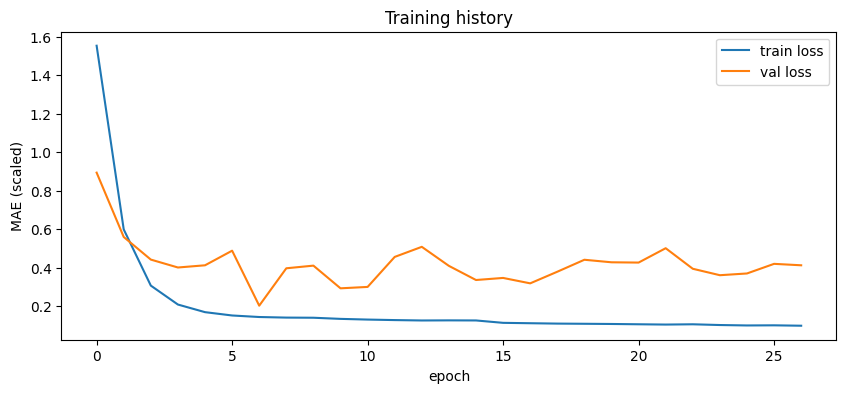

In [12]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("MAE (scaled)"); plt.legend()
plt.title("Training history")
plt.show()

Test set comparison ---
Naive baseline                 MAE=  4.011  RMSE=  5.908  MAPE= 3.99%  R2=0.9663
Linear Regression baseline     MAE=  5.124  RMSE=  7.074  MAPE= 5.14%  R2=0.9516
ANN (final model)              MAE= 10.762  RMSE= 13.254  MAPE=10.93%  R2=0.8302


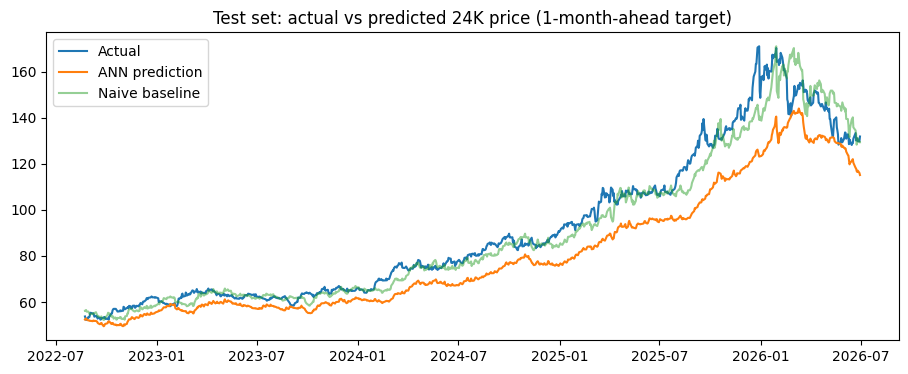

In [13]:
y_test_pred_s = final_model.predict(X_test_s, verbose=0).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_s.reshape(-1, 1)).ravel()

print("Test set comparison ---")
evaluate(y_test, naive_pred, "Naive baseline")
evaluate(y_test, lin_pred, "Linear Regression baseline")
ann_metrics = evaluate(y_test, y_test_pred, "ANN (final model)")

plt.figure(figsize=(11,4))
plt.plot(dates_test, y_test, label="Actual")
plt.plot(dates_test, y_test_pred, label="ANN prediction")
plt.plot(dates_test, naive_pred, label="Naive baseline", alpha=0.5)
plt.legend(); plt.title("Test set: actual vs predicted 24K price (1-month-ahead target)")
plt.show()

### Predicting Next Month + Karat Conversion + Buy/Sell Signal


In [14]:
latest_row = df[FEATURE_COLS].iloc[[-1]].values
latest_row_s = scaler_X.transform(latest_row)

pred_s = final_model.predict(latest_row_s, verbose=0).ravel()[0]
pred_24K = scaler_y.inverse_transform([[pred_s]])[0][0]

current_24K = df["24K"].iloc[-1]
pct_change = (pred_24K - current_24K) / current_24K * 100

karat_forecast = {
    "24K": pred_24K,
    "21K": pred_24K * 21/24,
    "18K": pred_24K * 18/24,
}

BUY_THRESHOLD, SELL_THRESHOLD = 2.0, -2.0   # % move considered "meaningful"
if pct_change > BUY_THRESHOLD:
    signal = "BUY NOW / SELL LATER — price expected to rise"
elif pct_change < SELL_THRESHOLD:
    signal = "WAIT TO BUY / SELL NOW — price expected to fall"
else:
    signal = "HOLD — no strong trend expected"

print(f"Current 24K price/gram: {current_24K:.2f}")
print(f"Predicted price/gram in ~1 month:")
for k, v in karat_forecast.items():
    print(f"  {k}: {v:.2f}")
print(f"\nExpected change: {pct_change:+.2f}%")
print(f"Signal: {signal}")
print("\n(Educational project! not financial advice!)")

Current 24K price/gram: 131.82
Predicted price/gram in ~1 month:
  24K: 114.58
  21K: 100.26
  18K: 85.93

Expected change: -13.08%
Signal: WAIT TO BUY / SELL NOW — price expected to fall

(Educational project — not financial advice.)
